In [69]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf
from tensorflow.keras import layers, models

In [70]:
input_path = '/kaggle/input/ravdess-emotional-speech-audio'
emotion_list = []
path_list=[]
input_dir=os.listdir(input_path)
for dir in input_dir:
    full_dir_path = os.path.join(input_path, dir)
    if os.path.isdir(full_dir_path):
        val = os.listdir(full_dir_path)
        for file in val:
            if file.endswith('.wav'):
                part = file.split('.')[0].split('-')
                if len(part) == 7:
                    emotion = int(part[2]) # part[2] holds emotion code
                    file_path = os.path.join(full_dir_path, file)
                    emotion_list.append(emotion)
                    path_list.append(file_path)
print(len(emotion_list), len(path_list))
print(emotion_list[:5])
print(path_list[:5])

1440 1440
[8, 1, 7, 7, 1]
['/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav']


In [71]:
emotion_df=pd.DataFrame(emotion_list, columns=['Emotions'])
path_df = pd.DataFrame(path_list, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)
Ravdess_df['Emotions'] = Ravdess_df['Emotions'].replace({
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'
})
data_path = pd.concat([Ravdess_df,], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/A...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/A...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/A...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/A...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/A...


In [72]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title(f'Waveplot for audio with "{e}" emotion', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

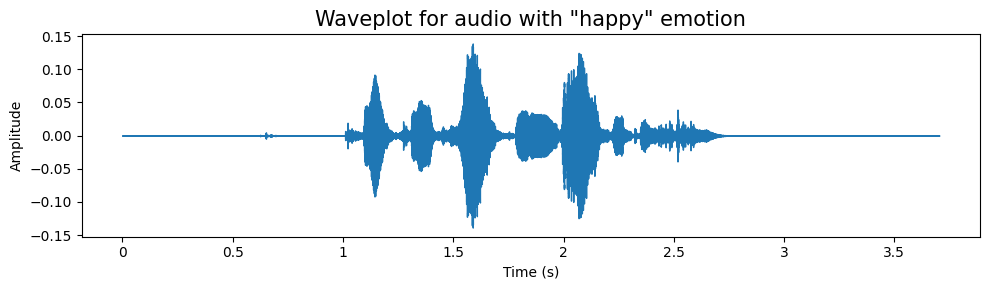

In [73]:
emotion='happy'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)

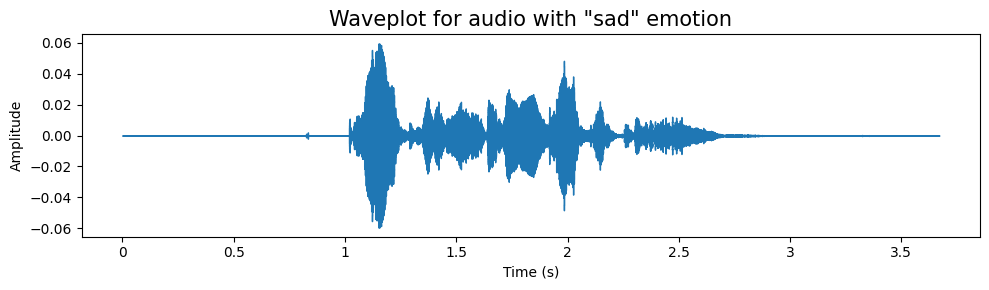

In [74]:
emotion='sad'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)

In [75]:
data,sample_rate=librosa.load(np.array(data_path.Path)[1])

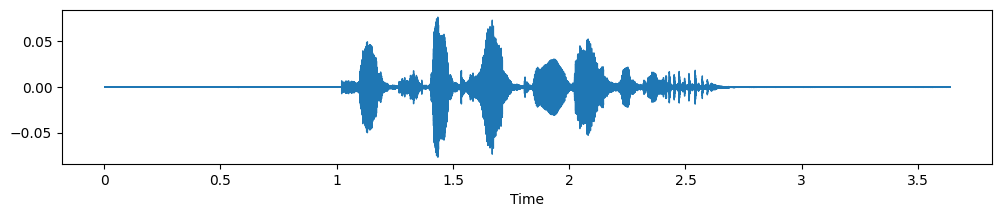

In [76]:
def noise(data):
    amp_noise=0.025*data.max()*np.random.uniform()
    data = data + amp_noise * np.random.normal(size=data.shape[0])
    return data
x=noise(data)
plt.figure(figsize=(12,2))
librosa.display.waveshow(y=x, sr=sample_rate)

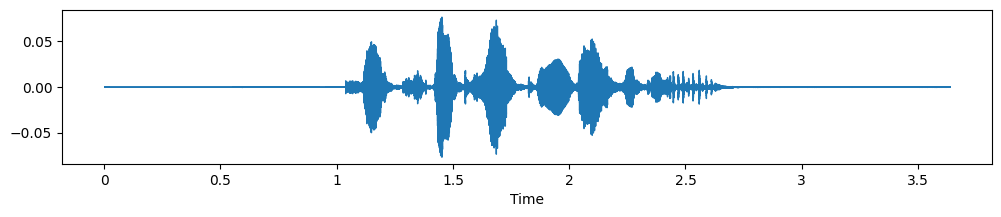

In [77]:
def phase_shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)
x=phase_shift(data)
plt.figure(figsize=(12,2))
librosa.display.waveshow(y=x, sr=sample_rate)

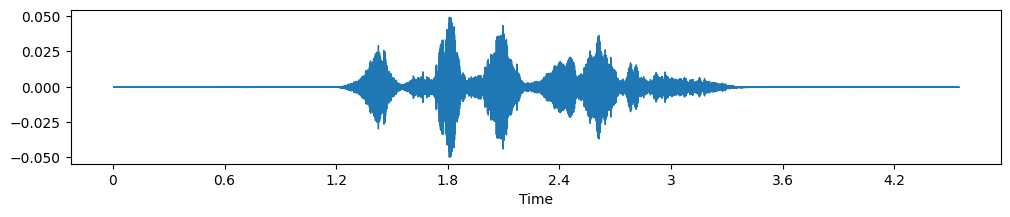

In [78]:
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate) 
x = stretch(data)
plt.figure(figsize=(12,2))
librosa.display.waveshow(y=x, sr=sample_rate)

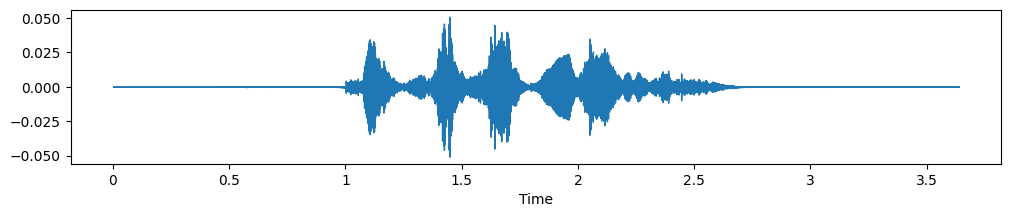

In [79]:
def pitch(data, sr, pitch_factor=0.7): 
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=pitch_factor) 
x = pitch(data, sample_rate)
plt.figure(figsize=(12,2))
librosa.display.waveshow(y=x, sr=sample_rate)

In [80]:
try:
    path_index = 1
    if len(data_path.Path) > path_index:
        path_to_load = data_path.Path[path_index]
        print(f"Loading audio from: {path_to_load}")
        data, sample_rate = librosa.load(path_to_load, sr=None) # sr=None loads original sample rate
        print(f"Original Data Shape: {data.shape}, Sample Rate: {sample_rate}")

        noisy_data = noise(data.copy())
        print(f"Noisy Data Shape: {noisy_data.shape}")

        stretched_data = stretch(data.copy(), rate=0.9)
        print(f"Stretched Data Shape: {stretched_data.shape}")

        shifted_data = phase_shift(data.copy())
        print(f"Shifted Data Shape: {shifted_data.shape}")

        pitched_data = pitch(data.copy(), sr=sample_rate, pitch_factor=1.2) # Using the updated 'pitch' function
        print(f"Pitched Data Shape: {pitched_data.shape}")

    else:
        print(f"Error: data_path.Path does not have an element at index {path_index}.")
except Exception as e:
    print(f"An error occurred during audio loading or processing: {e}")
    print("Please ensure 'data_path.Path' points to valid audio files.")

Loading audio from: /kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
Original Data Shape: (174574,), Sample Rate: 48000
Noisy Data Shape: (174574,)
Stretched Data Shape: (193971,)
Shifted Data Shape: (174574,)
Pitched Data Shape: (174574,)


In [81]:
def extract_features(data, sr):
    features = np.array([])
    
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data), axis=1) #Zero crossing rate
    features = np.hstack((features, zcr))
    
    stft = np.abs(librosa.stft(y=data)) #Short-time fourier transform
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr), axis=1)
    features = np.hstack((features, chroma_stft))

    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr), axis=1)  # Mel-Frequency Cepstral Coefficients
    features = np.hstack((features, mfcc))
    
    rms = np.mean(librosa.feature.rms(y=data), axis=1) #rms energy
    features = np.hstack((features, rms))

    mel_spectrogram = np.mean(librosa.feature.melspectrogram(y=data, sr=sr), axis=1) # Mel Spectrogram
    features = np.hstack((features, mel_spectrogram))

    return features

def get_features(path):
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6, sr=None) #None for passing default
    if data.ndim > 1:
        data = librosa.to_mono(data)

    # --- Feature extraction without augmentation ---
    res1 = extract_features(data, sample_rate)
    result = np.array(res1)

    # --- Feature extraction with noise augmentation ---
    noise_data = noise(data)
    res2 = extract_features(noise_data, sample_rate)
    result = np.vstack((result, res2))

    new_data = stretch(data) # stretch might implicitly use original sample rate or resample
    data_stretch_pitch = pitch(new_data, sample_rate) # Pass sample_rate to pitch
    res3 = extract_features(data_stretch_pitch, sample_rate)
    result = np.vstack((result, res3))

    return result

X, Y = [], []
for path, emotion in zip(data_path.Path, data_path.Emotions):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        Y.append(emotion)

len(X), len(Y), data_path.Path.shape

(4320, 4320, (1440,))

In [82]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.090058,0.673946,0.654692,0.609329,0.561602,0.577784,0.663767,0.695746,0.683081,0.678649,...,9.107989e-06,6.030573e-06,2.725033e-06,1.951339e-06,1.872080e-06,2.434932e-06,9.398871e-07,7.989661e-08,9.724439e-09,surprise
1,0.288653,0.703397,0.697967,0.680092,0.662621,0.714250,0.770041,0.748092,0.690871,0.691718,...,1.685830e-04,1.687095e-04,1.567017e-04,1.618174e-04,1.571034e-04,1.677379e-04,1.601384e-04,1.584278e-04,1.618132e-04,surprise
2,0.136497,0.707254,0.660559,0.592260,0.553595,0.540307,0.612870,0.645159,0.650890,0.649579,...,4.291800e-06,2.623575e-06,1.631588e-06,6.843705e-07,5.106019e-07,3.542810e-07,5.439314e-07,3.310524e-07,1.505434e-08,surprise
3,0.060322,0.613924,0.568585,0.598098,0.618646,0.619638,0.637888,0.683149,0.715577,0.691820,...,7.604099e-07,6.949188e-07,3.338844e-07,1.237676e-07,8.034726e-08,7.542826e-08,3.263111e-08,8.932885e-09,7.871676e-09,neutral
4,0.302211,0.684502,0.668302,0.707963,0.732051,0.729106,0.751418,0.756845,0.758832,0.744907,...,7.665658e-05,8.070324e-05,7.877336e-05,8.026046e-05,7.987829e-05,7.807937e-05,7.865646e-05,7.938638e-05,8.084888e-05,neutral


In [83]:
X = Features.iloc[:, :-1].values
Y = Features['labels'].values
encoder = OneHotEncoder(sparse_output=False) # sparse_output=False for numpy array output
Y = encoder.fit_transform(Y.reshape(-1, 1))

In [84]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0, shuffle=True)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

In [85]:
x_train = x_train[..., np.newaxis]  # (batch, timesteps, 1)
x_test  = x_test[..., np.newaxis]

In [86]:
input_dim = x_train.shape[1]  # number of features per sample
num_classes = y_train.shape[1]




model = models.Sequential([
    layers.Input(shape=(input_dim, 1)),
    
    layers.Conv1D(64, 3, padding='same', activation=tf.keras.activations.swish),
    layers.BatchNormalization(),
    layers.MaxPool1D(2),
    
    layers.Conv1D(128, 3, padding='same', activation=tf.keras.activations.swish),
    layers.BatchNormalization(),
    layers.MaxPool1D(2),
    
    layers.Conv1D(256, 3, padding='same', activation=tf.keras.activations.swish),
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(),

    layers.Dense(128, activation=tf.keras.activations.swish),
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 162, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 162, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 81, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 81, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 81, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 40, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,240 (622.03 KB)

 Trainable params: 158,344 (618.53 KB)

 Non-trainable params: 896 (3.50 KB)

In [88]:
callbacks=[tf.keras.callbacks.ReduceLROnPlateau(patience=2,factor=0.4,min_lr=1e-7,verbose=1),
           tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)]
history=model.fit(x_train,y_train,
          validation_data=(x_test,y_test),
          epochs=100,
          batch_size=64,
          callbacks=callbacks)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.2666 - loss: 1.8757 - val_accuracy: 0.1620 - val_loss: 2.0515 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3388 - loss: 1.7497 - val_accuracy: 0.1262 - val_loss: 2.0385 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3385 - loss: 1.7055 - val_accuracy: 0.1667 - val_loss: 2.0439 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3947 - loss: 1.5929 - val_accuracy: 0.1794 - val_loss: 1.9951 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4177 - loss: 1.5178 - val_accuracy: 0.2303 - val_loss: 1.9823 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4540 - loss: 1.4316 - val_accuracy: 0.2847 - val_loss: 1.8375 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.4877 - loss: 1.3769 - 

In [89]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.7037


In [90]:

from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

# Predict class indices from probabilities
y_probs = model.predict(x_test)
y_pred_indices = np.argmax(y_probs, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

# Inverse transform to original labels
y_pred_original_labels = encoder.inverse_transform(np.eye(num_classes)[y_pred_indices]).flatten()
y_test_original_labels = encoder.inverse_transform(np.eye(num_classes)[y_test_indices]).flatten()

# Create DataFrame for Predicted vs Actual Labels
df = pd.DataFrame({
    'Predicted Labels': y_pred_original_labels,
    'Actual Labels': y_test_original_labels
})

print("\n--- 🔎 Sample of Predicted vs Actual Labels ---")
print(df.head(10))

# Classification Report
print("\n--- 📊 Classification Report ---")
print(classification_report(
    y_test_original_labels,
    y_pred_original_labels,
    target_names=encoder.categories_[0]
))


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- 🔎 Sample of Predicted vs Actual Labels ---
  Predicted Labels Actual Labels
0             fear          fear
1             calm       neutral
2              sad           sad
3              sad       neutral
4             fear          fear
5            angry         angry
6             fear          fear
7             fear          fear
8          disgust       disgust
9             calm          calm

--- 📊 Classification Report ---
              precision    recall  f1-score   support

       angry       0.78      0.68      0.73       116
        calm       0.75      0.83      0.79       104
     disgust       0.70      0.65      0.68       113
        fear       0.72      0.75      0.73       126
       happy       0.70      0.65      0.67       123
     neutral       0.68      0.56      0.61        68
         sad       0.62      0.68      0.65       111
    surprise       0.68      0.79      0.73       103

    accuracy                 

In [91]:
!pip install openai-whisper google-generativeai

In [93]:
import whisper
import google.generativeai as genai
import json

In [94]:
GEMINI_API_KEY = "my-api-key"

genai.configure(api_key=GEMINI_API_KEY)

llm_model = genai.GenerativeModel("models/gemini-2.5-flash")

In [96]:
whisper_model = whisper.load_model("base")

In [98]:
def predict_emotion(audio_path):

    data, sr = librosa.load(
        audio_path,
        duration=2.5,
        offset=0.6
    )

    feature = extract_features(data, sr)

    feature = np.array(feature)

    feature = scaler.transform([feature])

    feature = np.expand_dims(feature, axis=2)

    prediction = model.predict(feature)

    predicted_emotion = encoder.inverse_transform(prediction)[0][0]

    return predicted_emotion

In [100]:
def transcribe_audio(audio_path):

    result = whisper_model.transcribe(audio_path)

    transcript = result["text"]

    return transcript

In [101]:
def generate_llm_insights(transcript, emotion):

    prompt = f"""
    You are an AI speech emotion analysis assistant.

    Analyze the following speech transcript and detected emotion.

    Transcript:
    {transcript}

    Detected Emotion:
    {emotion}

    Generate:
    1. Conversation summary
    2. Emotional tone
    3. Stress level
    4. Communication insights
    5. Recommendation

    Return output strictly in JSON format.
    """

    response = llm_model.generate_content(prompt)

    return response.text

In [103]:
def analyze_speech(audio_path):

    predicted_emotion = predict_emotion(audio_path)

    transcript = transcribe_audio(audio_path)

    llm_analysis = generate_llm_insights(
        transcript,
        predicted_emotion
    )

    final_output = {
        "predicted_emotion": predicted_emotion,
        "transcript": transcript,
        "llm_analysis": llm_analysis
    }

    return final_output

In [104]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [105]:
audio_path = "/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav"

result = analyze_speech(audio_path)

print(json.dumps(result, indent=4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


{
    "predicted_emotion": "surprise",
    "transcript": " Kids are talking by the door.",
    "llm_analysis": "```json\n{\n  \"conversation_summary\": \"The speaker is making a real-time observation that children are present and speaking near the door. The detected emotion suggests that this event or their vocal activity was unexpected for the speaker.\",\n  \"emotional_tone\": \"The primary emotional tone is surprise. This indicates that the speaker was caught off guard or found the presence and activity of the children by the door to be unanticipated. It implies an unexpected observation rather than a strong positive or negative emotional response.\",\n  \"stress_level\": \"The stress level appears to be low. The surprise seems to stem from an unexpected observation rather than a reaction to a threatening or highly demanding situation. It suggests a mild, cognitive surprise, not typically associated with high physiological stress.\",\n  \"communication_insights\": [\n    \"The speak